In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

LOAD DATA

In [2]:
# Load processed training and test data

X_train_processed = joblib.load(
    "X_train_processed.pkl"
)

X_test_processed = joblib.load(
    "X_test_processed.pkl"
)

y_train = joblib.load(
    "y_train.pkl"
)

y_test = joblib.load(
    "y_test.pkl"
)


print(
    "Training data:",
    X_train_processed.shape
)

print(
    "Test data:",
    X_test_processed.shape
)

Training data: (20000, 43)
Test data: (5000, 43)


Load the selected XGBoost parameters

In [3]:
# Load the hyperparameters selected during GridSearchCV

xgb_best_params = joblib.load(
    "../models/xgboost_best_params.pkl"
)


print(
    "Selected XGBoost parameters:"
)

print(
    xgb_best_params
)

Selected XGBoost parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


Create the validation set

In [5]:
# Split ONLY the training data
# Test data remains completely untouched

X_xgb_train, X_xgb_validation, y_xgb_train, y_xgb_validation = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)


print(
    "XGBoost training:",
    X_xgb_train.shape
)

print(
    "XGBoost validation:",
    X_xgb_validation.shape
)

XGBoost training: (16000, 43)
XGBoost validation: (4000, 43)


Train the tuned XGBoost on the 16,000 training rows

In [6]:
# Train XGBoost using the hyperparameters
# selected during the previous tuning experiment

validation_xgb = XGBClassifier(
    **xgb_best_params,
    random_state=42,
    eval_metric="logloss"
)


validation_xgb.fit(
    X_xgb_train,
    y_xgb_train
)


print(
    "Validation model trained successfully."
)

Validation model trained successfully.


Get validation probabilities

In [7]:
# Predict probabilities on the validation set

validation_probability = validation_xgb.predict_proba(
    X_xgb_validation
)[:, 1]


print(
    validation_probability[:20]
)

[1.21178653e-03 3.85340187e-04 4.07514046e-04 1.14783434e-04
 4.22123994e-04 2.67652646e-02 6.91377521e-02 2.97087152e-03
 9.80712473e-04 1.26974715e-03 4.77085356e-04 9.90974605e-01
 4.48579073e-01 4.45793420e-01 3.70731682e-01 5.93011442e-04
 8.90386462e-01 6.74024457e-04 9.69559014e-01 3.09123076e-04]


Search thresholds

In [8]:
# Evaluate different classification thresholds

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)


threshold_results = []


for threshold in thresholds:

    validation_predictions = (
        validation_probability >= threshold
    ).astype(int)


    threshold_results.append({

        "Threshold": round(
            threshold,
            2
        ),

        "Precision": precision_score(
            y_xgb_validation,
            validation_predictions
        ),

        "Recall": recall_score(
            y_xgb_validation,
            validation_predictions
        ),

        "F1 Score": f1_score(
            y_xgb_validation,
            validation_predictions
        )
    })


threshold_df = pd.DataFrame(
    threshold_results
)


threshold_df.head()

,Threshold,Precision,Recall,F1 Score
0,0.10,0.660625,0.990628,0.792651
1,0.11,0.665617,0.990628,0.796234
2,0.12,0.671964,0.990628,0.800758
3,0.13,0.679537,0.989691,0.805799
4,0.14,0.682171,0.989691,0.807648


Find best F1 threshold

In [10]:
# Find the threshold with the highest F1 Score

best_f1_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best threshold by F1:")
print(best_f1_row)

Best threshold by F1:
Threshold    0.310000
Precision    0.737787
Recall       0.962512
F1 Score     0.835299
Name: 21, dtype: float64


Business cost on validation data

In [11]:
# Business Cost Analysis on Validation Data

# These are example costs.
# Replace them if you later obtain real business costs.

fp_cost = 1000
fn_cost = 10000

validation_cost_results = []

for threshold in thresholds:

    validation_predictions = (
        validation_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_xgb_validation,
        validation_predictions
    ).ravel()

    total_cost = (
        fp * fp_cost
        +
        fn * fn_cost
    )

    validation_cost_results.append({
        "Threshold": round(threshold, 2),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Total Cost": total_cost
    })

validation_cost_df = pd.DataFrame(
    validation_cost_results
)

validation_cost_df

,Threshold,TN,FP,FN,TP,Total Cost
0,0.10,2390,543,10,1057,643000
1,0.11,2402,531,10,1057,631000
2,0.12,2417,516,10,1057,616000
3,0.13,2435,498,11,1056,608000
4,0.14,2441,492,11,1056,602000
...,...,...,...,...,...,...
76,0.86,2915,18,579,488,5808000
77,0.87,2918,15,587,480,5885000
78,0.88,2918,15,594,473,5955000
79,0.89,2919,14,607,460,6084000


Select the business-cost threshold

In [17]:
# Find the threshold with the lowest validation business cost
# This is reported as a business-cost sensitivity analysis.
# It is NOT our final threshold because the costs are assumed.

best_business_row = validation_cost_df.loc[
    validation_cost_df["Total Cost"].idxmin()
]

best_business_threshold = float(
    best_business_row["Threshold"]
)

print(
    "Best threshold by business cost:",
    best_business_threshold
)

print(
    "\nBusiness-cost result:"
)

print(
    best_business_row
)

Best threshold by business cost: 0.15

Business-cost result:
Threshold          0.15
TN              2448.00
FP               485.00
FN                11.00
TP              1056.00
Total Cost    595000.00
Name: 5, dtype: float64


Compare F1 threshold and business threshold

In [20]:
# Compare F1-based and business-cost-based thresholds

print("Best threshold by F1:")
print(best_f1_row)

print("\n" + "=" * 60 + "\n")

print("Best threshold by business cost:")
print(best_business_row)

Best threshold by F1:
Threshold    0.310000
Precision    0.737787
Recall       0.962512
F1 Score     0.835299
Name: 21, dtype: float64


Best threshold by business cost:
Threshold          0.15
TN              2448.00
FP               485.00
FN                11.00
TP              1056.00
Total Cost    595000.00
Name: 5, dtype: float64


In [21]:
# Select the final operating threshold
# based on the highest validation F1 score

final_threshold = float(
    best_f1_row["Threshold"]
)

print(
    "Final selected threshold:",
    final_threshold
)

Final selected threshold: 0.31


Train the final XGBoost

In [22]:
# Train the FINAL XGBoost model
# using all available training data

final_xgb = XGBClassifier(
    **xgb_best_params,
    random_state=42,
    eval_metric="logloss"
)

final_xgb.fit(
    X_train_processed,
    y_train
)

print("Final XGBoost model trained successfully.")
print("Training samples used:", len(y_train))

Final XGBoost model trained successfully.
Training samples used: 20000


Get final probabilities from TEST

In [23]:
# Generate probabilities on the untouched test set

final_test_probability = final_xgb.predict_proba(
    X_test_processed
)[:, 1]

print(final_test_probability[:20])

[6.6253007e-04 9.8581737e-01 1.0778403e-03 7.3045935e-03 5.1714784e-01
 3.8986563e-04 7.6714742e-01 7.9428911e-01 3.2344359e-04 4.6718803e-01
 4.1372105e-01 8.9882091e-02 9.9313700e-01 2.2272356e-02 1.2792508e-03
 5.5098569e-04 1.7693416e-04 3.8577017e-01 3.0122256e-02 7.1967649e-01]


Final test prediction using our 0.31 threshold

In [24]:
# Apply the threshold selected from validation data

final_test_pred = (
    final_test_probability >= final_threshold
).astype(int)

print("Final operating threshold:", final_threshold)

Final operating threshold: 0.31


Final confusion matrix

In [25]:
# Final Confusion Matrix

final_cm = confusion_matrix(
    y_test,
    final_test_pred
)

print("Final XGBoost Confusion Matrix:")
print(final_cm)

Final XGBoost Confusion Matrix:
[[3154  512]
 [  50 1284]]


Final classification report

In [26]:
# Final Classification Report

print(
    classification_report(
        y_test,
        final_test_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.86      0.92      3666
           1       0.71      0.96      0.82      1334

    accuracy                           0.89      5000
   macro avg       0.85      0.91      0.87      5000
weighted avg       0.91      0.89      0.89      5000



In [27]:
# Final ROC-AUC

final_roc_auc = roc_auc_score(
    y_test,
    final_test_probability
)

print(
    "Final ROC-AUC:",
    final_roc_auc
)

Final ROC-AUC: 0.9678362537225659


In [28]:
# Final PR-AUC

final_pr_auc = average_precision_score(
    y_test,
    final_test_probability
)

print(
    "Final PR-AUC:",
    final_pr_auc
)

Final PR-AUC: 0.915329674954825


In [29]:
# Create one final metrics table

final_tn, final_fp, final_fn, final_tp = confusion_matrix(
    y_test,
    final_test_pred
).ravel()

final_metrics = {
    "Model": "Final XGBoost",
    "Threshold": final_threshold,

    "Accuracy": accuracy_score(
        y_test,
        final_test_pred
    ),

    "Precision": precision_score(
        y_test,
        final_test_pred
    ),

    "Recall": recall_score(
        y_test,
        final_test_pred
    ),

    "F1 Score": f1_score(
        y_test,
        final_test_pred
    ),

    "ROC-AUC": final_roc_auc,

    "PR-AUC": final_pr_auc,

    "TN": final_tn,
    "FP": final_fp,
    "FN": final_fn,
    "TP": final_tp
}

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

final_metrics_df

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Final XGBoost,0.31,0.8876,0.714922,0.962519,0.820447,0.967836,0.91533,3154,512,50,1284


Final business cost on TEST

In [30]:
# Final business cost on the test set
# This is reporting only.

final_test_cost = (
    final_fp * fp_cost
    +
    final_fn * fn_cost
)

print(
    "Final Test Business Cost:",
    final_test_cost
)

print(
    "False Positives:",
    final_fp
)

print(
    "False Negatives:",
    final_fn
)

Final Test Business Cost: 1012000
False Positives: 512
False Negatives: 50


Compare standard 0.50 vs final 0.31

In [31]:
# Compare the standard threshold with our selected threshold

comparison_threshold_df = pd.DataFrame([
    {
        "Threshold": 0.50,
        "Precision": precision_score(
            y_test,
            (final_test_probability >= 0.50).astype(int)
        ),
        "Recall": recall_score(
            y_test,
            (final_test_probability >= 0.50).astype(int)
        ),
        "F1 Score": f1_score(
            y_test,
            (final_test_probability >= 0.50).astype(int)
        )
    },

    {
        "Threshold": final_threshold,
        "Precision": precision_score(
            y_test,
            final_test_pred
        ),
        "Recall": recall_score(
            y_test,
            final_test_pred
        ),
        "F1 Score": f1_score(
            y_test,
            final_test_pred
        )
    }
])

comparison_threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.50,0.798697,0.826837,0.812523
1,0.31,0.714922,0.962519,0.820447


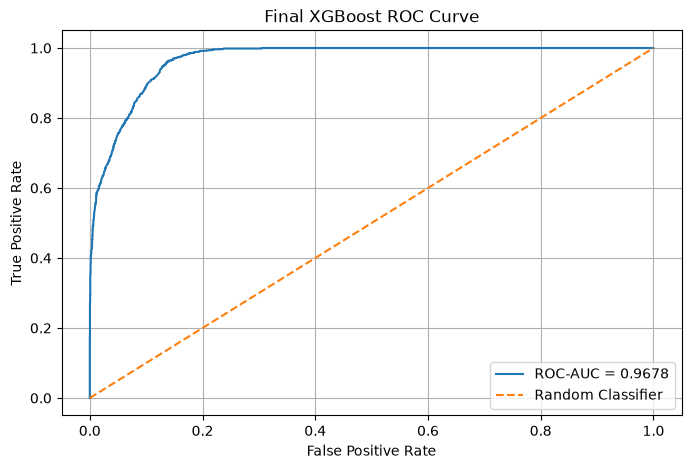

In [32]:
# Final XGBoost ROC Curve

from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    final_test_probability
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {final_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Final XGBoost ROC Curve"
)

plt.legend()
plt.grid()

plt.show()

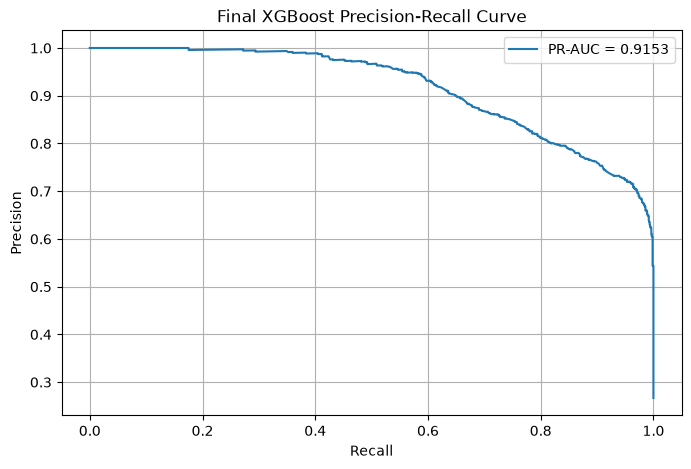

In [33]:
# Final XGBoost Precision-Recall Curve

from sklearn.metrics import precision_recall_curve

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    final_test_probability
)

plt.figure(figsize=(8, 5))

plt.plot(
    recall_values,
    precision_values,
    label=f"PR-AUC = {final_pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Final XGBoost Precision-Recall Curve"
)

plt.legend()
plt.grid()

plt.show()

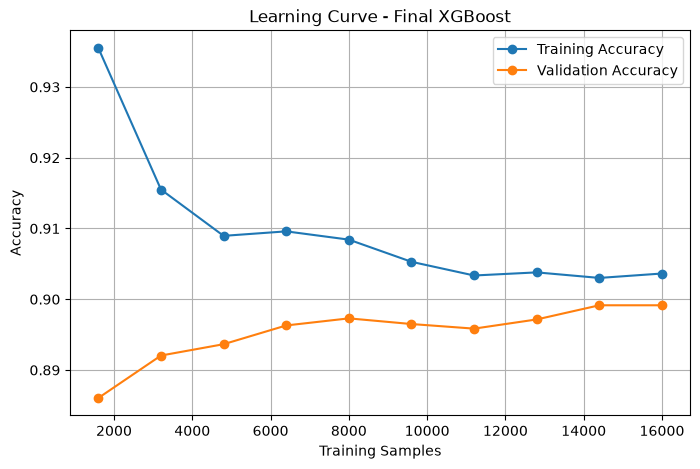

In [34]:
# Learning Curve - Final XGBoost

from sklearn.model_selection import learning_curve

train_sizes, train_scores, validation_scores = learning_curve(
    final_xgb,
    X_train_processed,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(
        0.1,
        1.0,
        10
    ),
    n_jobs=-1
)

train_mean = train_scores.mean(
    axis=1
)

validation_mean = validation_scores.mean(
    axis=1
)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel(
    "Training Samples"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Learning Curve - Final XGBoost"
)

plt.legend()
plt.grid()

plt.show()

XGBoost feature importance

In [36]:
# XGBoost Feature Importance

# Get feature names from the preprocessing object
# Try the common preprocessing variable names

feature_names = None

for name in [
    "preprocessor",
    "processor",
    "preprocess",
    "transformer"
]:
    if name in globals() and hasattr(
        globals()[name],
        "get_feature_names_out"
    ):
        feature_names = globals()[name].get_feature_names_out()
        print("Feature names obtained from:", name)
        break


# If feature names cannot be found,
# create safe generic names

if feature_names is None:

    feature_names = [
        f"Feature_{i}"
        for i in range(
            X_train_processed.shape[1]
        )
    ]

    print(
        "Preprocessor feature names not found."
    )

    print(
        "Using generic feature names."
    )


feature_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": final_xgb.feature_importances_

})


feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Number of features:",
    len(feature_names)
)

feature_importance_df.head(20)

Preprocessor feature names not found.
Using generic feature names.
Number of features: 43


,Feature,Importance
0,Feature_25,0.283717
1,Feature_41,0.224133
2,Feature_24,0.171620
3,Feature_36,0.051154
4,Feature_42,0.046830
5,Feature_37,0.045388
6,Feature_33,0.035606
7,Feature_38,0.026742
8,Feature_35,0.025758
9,Feature_34,0.024693


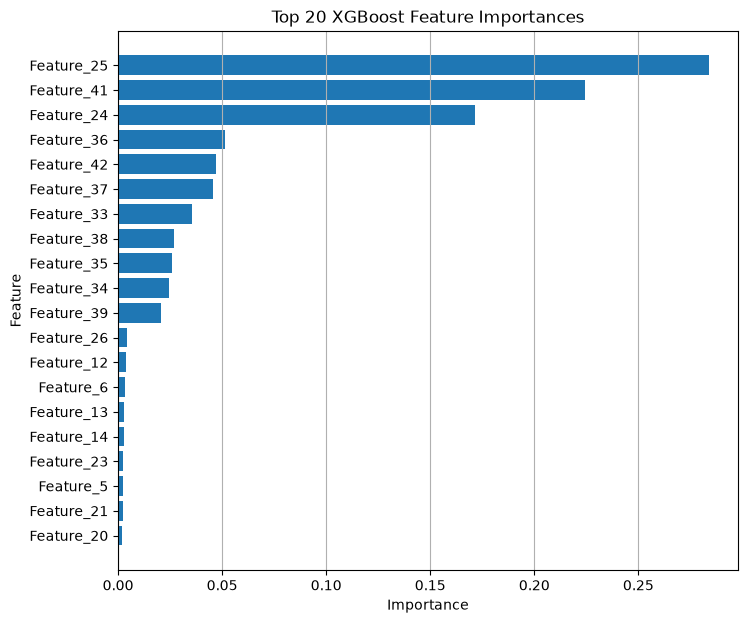

In [37]:
# Plot Top 20 XGBoost Feature Importances

top_features = feature_importance_df.head(20)

plt.figure(figsize=(8, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 20 XGBoost Feature Importances"
)

plt.grid(axis="x")

plt.show()

In [38]:
# Save the final XGBoost model
# together with the selected operating threshold

final_model_bundle = {
    "model": final_xgb,
    "threshold": final_threshold
}

joblib.dump(
    final_model_bundle,
    "../models/final_xgboost_model.pkl"
)

print(
    "Final XGBoost model saved successfully."
)

print(
    "Saved threshold:",
    final_threshold
)

Final XGBoost model saved successfully.
Saved threshold: 0.31


FINAL REPORTS

In [39]:
# Save final evaluation reports

final_metrics_df.to_csv(
    "../reports/final_xgboost_metrics.csv",
    index=False
)

threshold_df.to_csv(
    "../reports/xgboost_validation_thresholds.csv",
    index=False
)

validation_cost_df.to_csv(
    "../reports/xgboost_validation_business_cost.csv",
    index=False
)

comparison_threshold_df.to_csv(
    "../reports/xgboost_threshold_comparison.csv",
    index=False
)

feature_importance_df.to_csv(
    "../reports/xgboost_feature_importance.csv",
    index=False
)

print(
    "All final XGBoost reports saved successfully."
)

All final XGBoost reports saved successfully.


In [40]:
# Verify the saved final model

loaded_bundle = joblib.load(
    "../models/final_xgboost_model.pkl"
)

loaded_model = loaded_bundle["model"]

loaded_threshold = loaded_bundle["threshold"]

print(
    "Loaded model:",
    type(loaded_model).__name__
)

print(
    "Loaded threshold:",
    loaded_threshold
)

Loaded model: XGBClassifier
Loaded threshold: 0.31


In [1]:
import sklearn
import xgboost

print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)

scikit-learn: 1.9.1
XGBoost: 3.4.1
